<a href="https://colab.research.google.com/github/KanishkaGajendran/Miniproject5/blob/main/Mini_Project5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


#**AI Echo: Your Smartest Conversational Partner**


In [1]:
#Read the file
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

from google.colab import files
uploaded = files.upload()

Saving chatgpt_style_reviews_dataset.xlsx to chatgpt_style_reviews_dataset.xlsx


In [2]:

#Read the file
df=pd.read_excel('chatgpt_style_reviews_dataset.xlsx')
df.head()

,date,title,review,rating,username,helpful_votes,review_length,platform,language,location,version,verified_purchase
0,2024-09-06 00:00:00,Claim who accept.,Every quite sense including six lot have never...,4,morrowthomas,30,22,Flipkart,ar,Nepal,3.8.4,No
1,2025-03-07 00:00:00,Growth pretty wish.,Ask develop bag also his worker pass. Expert w...,4,sheakimberly,120,22,Flipkart,ar,Guinea,5.2.6,Yes
2,########,What then spend offer reason whom none.,If customer address region try near risk next ...,5,katherineali,130,21,Flipkart,es,Kuwait,3.6.5,No
3,########,Say dog drug enter director strong student.,To television loss election him small detail r...,1,eric11,72,26,Amazon,pt,Uruguay,5.7.2,No
4,########,Purpose here beyond.,Pass share must amount lot per manage world to...,5,chloe42,123,27,Amazon,zh,Mayotte,5.8.6,No


In [3]:
#Data preprocessing
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   date               250 non-null    object
 1   title              250 non-null    object
 2   review             250 non-null    object
 3   rating             250 non-null    int64 
 4   username           250 non-null    object
 5   helpful_votes      250 non-null    int64 
 6   review_length      250 non-null    int64 
 7   platform           250 non-null    object
 8   language           250 non-null    object
 9   location           250 non-null    object
 10  version            250 non-null    object
 11  verified_purchase  250 non-null    object
dtypes: int64(3), object(9)
memory usage: 23.6+ KB


In [4]:
df['date'] = (df['date'].astype(str).replace('########', pd.NA)).astype('datetime64[ns]')
df['date'] = df['date'].ffill()


In [40]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

#Intialize
stop_words = set(stopwords.words('english'))

custom_stopwords = stop_words.union({
    'red', 'paper', 'exist', 'manager', 'piece', 'goal',
    'would', 'could', 'also', 'one', 'get', 'like'
})

lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    if pd.isna(text):
        return ''

    #Lowercase
    text = text.lower()
    #Remove repeated characters
    text = re.sub(r'(.)\1+', r'\1\1', text)
    #Remove numbers & special charcaters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    #Tokenize
    words = text.split()
    #rmove stopwords+lemmatize
    words = [lemmatizer.lemmatize(word)
    for word in words
    if word not in custom_stopwords and len(word) > 2]

    return ' '.join(words)

df=df[df['sentiment']!="Unknown"]

df['title'] = df['title'].apply(preprocess_text)
df['review'] = df['review'].apply(preprocess_text)
#Remove empty rows
df = df[df['title'].str.strip() != ""]
df = df[df['review'].str.strip() != ""]

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [42]:
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

df=df.dropna(subset=['rating'])

def rating_sentiment(rating):
  if rating >= 4:
    return "Positive"
  elif rating == 3:
    return "Neutral"
  else:
    return "Negative"

df["sentiment"] = df["rating"].apply(rating_sentiment)

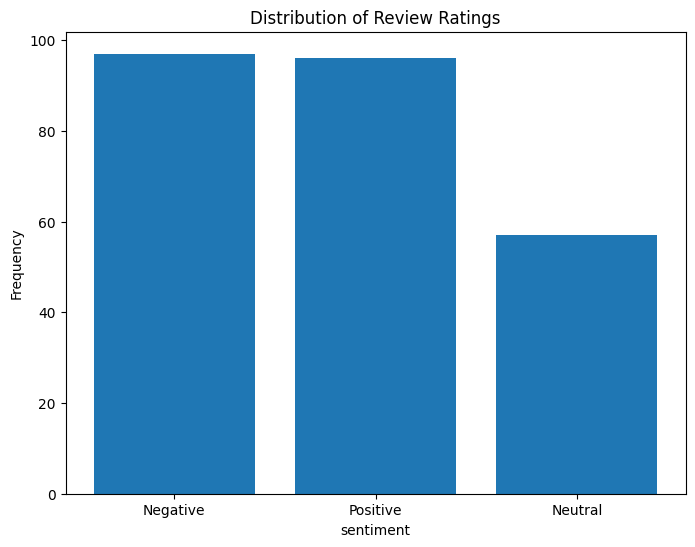

In [43]:
#Exploratory Data Analysis
#What is the distribution of review ratings

plt.figure(figsize=(8, 6))
plt.bar(df['sentiment'].value_counts().index, df['sentiment'].value_counts().values)
plt.title('Distribution of Review Ratings')
plt.xlabel('sentiment')
plt.ylabel('Frequency')
plt.show()


Number of reviews marked as helpful: 240
Number of reviews marked as not helpful: 10


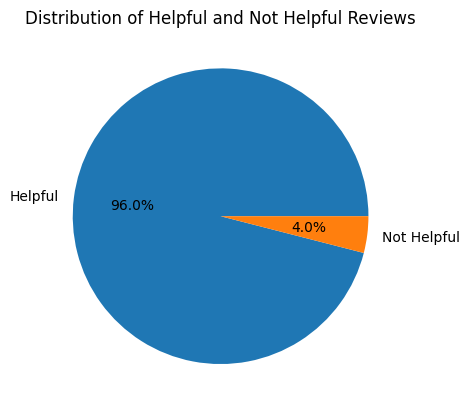

In [44]:
#How many reviews were marked as helpful (above a certain threshold)
threshold = 5
helpful_reviews = df[df['helpful_votes'] >= threshold]
print(f"Number of reviews marked as helpful: {len(helpful_reviews)}")
not_helpful_reviews = df[df['helpful_votes'] < threshold]
print(f"Number of reviews marked as not helpful: {len(not_helpful_reviews)}")

labels = ['Helpful', 'Not Helpful']
counts = [len(helpful_reviews), len(not_helpful_reviews)]

plt.pie(counts, labels=labels, autopct='%1.1f%%')
plt.title('Distribution of Helpful and Not Helpful Reviews')
plt.show()

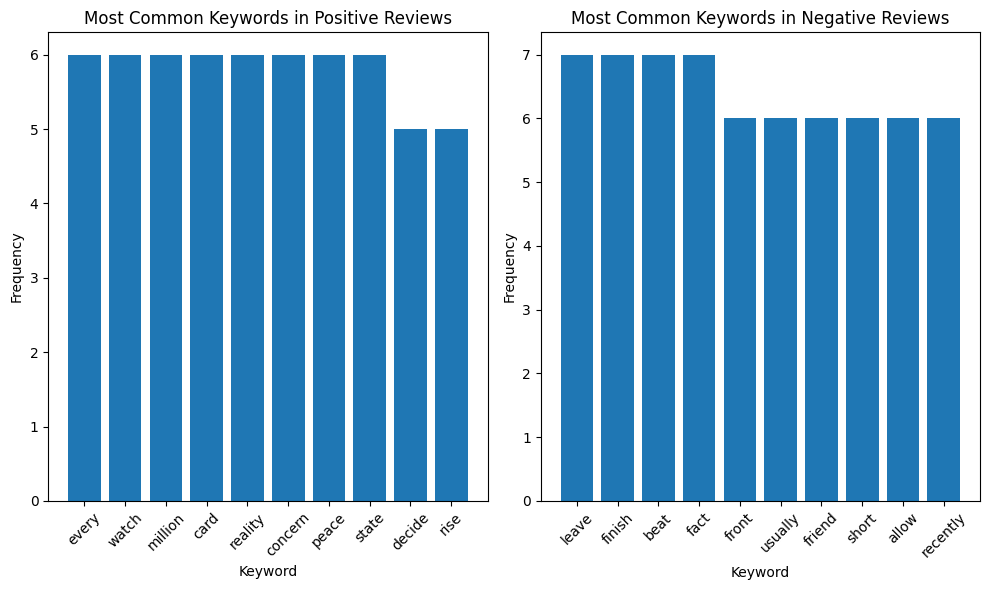

In [45]:
#What are the most common keywords in positive vs. negative reviews
from wordcloud import WordCloud

positive_reviews = df[df['sentiment'] == 'Positive']
negative_reviews = df[df['sentiment'] == 'Negative']

positive_keywords = ' '.join(positive_reviews['review']).split()
negative_keywords = ' '.join(negative_reviews['review']).split()

positive_keyword_counts = pd.Series(positive_keywords).value_counts().head(10)
negative_keyword_counts = pd.Series(negative_keywords).value_counts().head(10)

plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.bar(positive_keyword_counts.index, positive_keyword_counts.values)
plt.title('Most Common Keywords in Positive Reviews')
plt.xlabel('Keyword')
plt.xticks(rotation=45)
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.bar(negative_keyword_counts.index, negative_keyword_counts.values)
plt.title('Most Common Keywords in Negative Reviews')
plt.xlabel('Keyword')
plt.xticks(rotation=45)
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

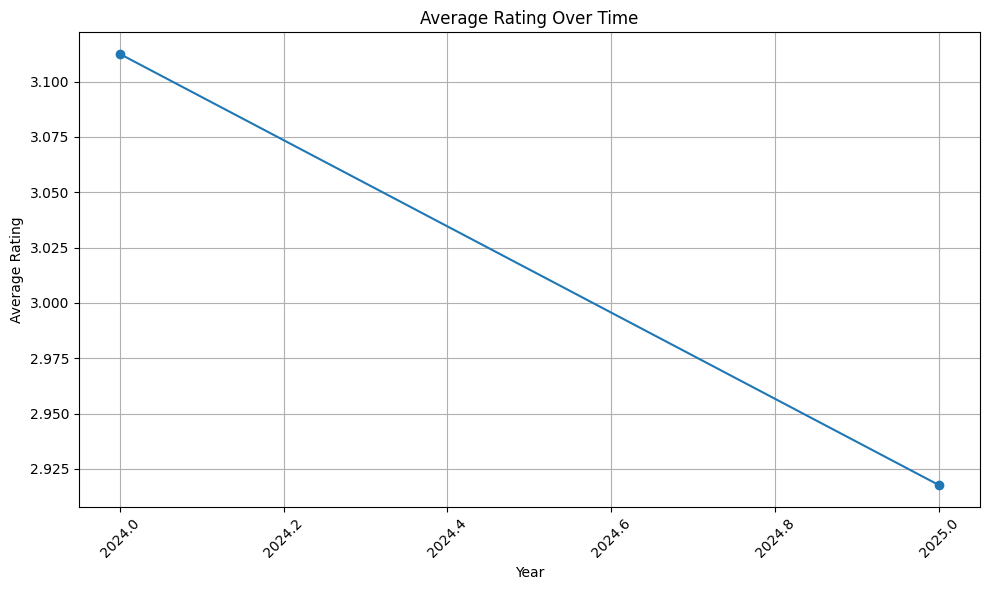

In [46]:
#How has the average rating changed over time
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df=df.dropna(subset=['date','rating'])
average_ratings = df.groupby(df['date'].dt.year)['rating'].mean()
average_ratings = average_ratings.sort_index()

plt.figure(figsize=(10, 6))
plt.plot(average_ratings.index, average_ratings.values,marker='o', linestyle='-')
plt.title('Average Rating Over Time')
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [47]:
#How do ratings vary by user location
import plotly.express as px
user_location_ratings = df.groupby('location')['rating'].mean()
fig = px.choropleth(locations=user_location_ratings.index,
                    locationmode='country names',
                    color=user_location_ratings.values, color_continuous_scale='Viridis',
                    title='Ratings by User Location')
fig.show()



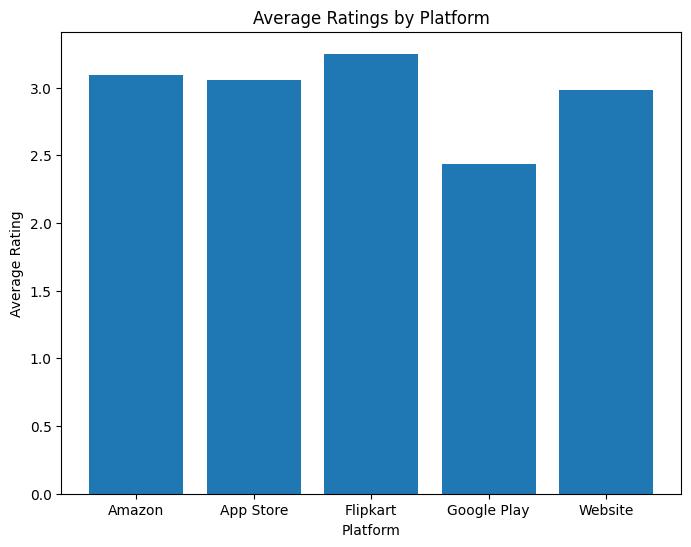

In [48]:
#Which platform (Web vs Mobile) gets better reviews
platform_ratings = df.groupby('platform')['rating'].mean()
plt.figure(figsize=(8, 6))
plt.bar(platform_ratings.index, platform_ratings.values)
plt.title('Average Ratings by Platform')
plt.xlabel('Platform')
plt.ylabel('Average Rating')
plt.show()



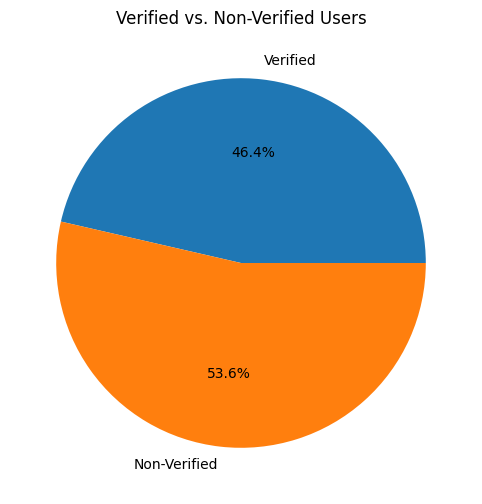

In [49]:
#Are verified users more satisfied than non-verified ones
verified_ratings = df[df['verified_purchase'] == 'Yes']['sentiment']
non_verified_ratings = df[df['verified_purchase'] == 'No']['sentiment']
plt.figure(figsize=(8, 6))
plt.pie([len(verified_ratings), len(non_verified_ratings)], labels=['Verified', 'Non-Verified'], autopct='%1.1f%%')
plt.title('Verified vs. Non-Verified Users')
plt.show()

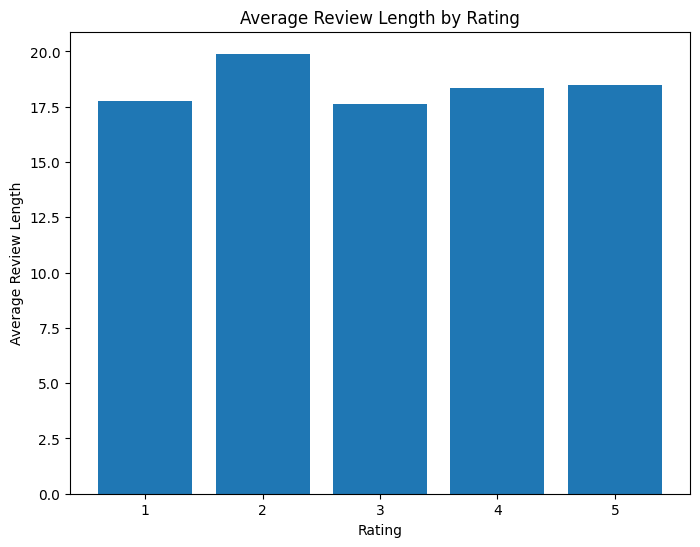

In [50]:
#What’s the average length of reviews per rating category
df['review_length'] = df['review'].apply(lambda x: len(x.split()))
average_length_by_rating = df.groupby('rating')['review_length'].mean()
plt.figure(figsize=(8, 6))
plt.bar(average_length_by_rating.index, average_length_by_rating.values)
plt.title('Average Review Length by Rating')
plt.xlabel('Rating')
plt.ylabel('Average Review Length')
plt.show()

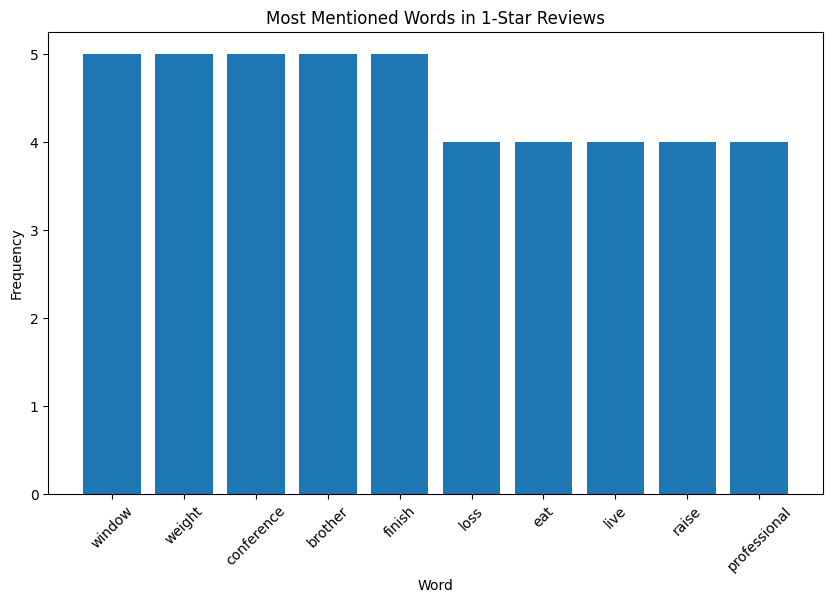

In [51]:
#What are the most mentioned words in 1-star reviews
from collections import Counter
one_star_reviews = df[df['rating'] == 1]['review']
one_star_words = ' '.join(one_star_reviews).split()
one_star_word_counts = Counter(one_star_words)
most_mentioned_words = one_star_word_counts.most_common(10)
words, counts = zip(*most_mentioned_words)
plt.figure(figsize=(10, 6))
plt.bar(words, counts)
plt.title('Most Mentioned Words in 1-Star Reviews')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()


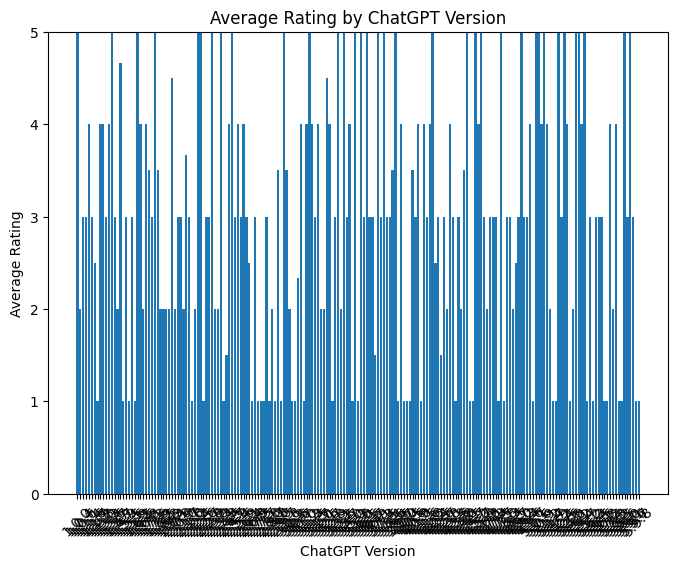

In [52]:
#What ChatGPT version received the highest average rating
average_rating_by_version = df.groupby('version')['rating'].mean()

plt.figure(figsize=(8, 6))
plt.bar(average_rating_by_version.index, average_rating_by_version.values)
plt.title('Average Rating by ChatGPT Version')
plt.xlabel('ChatGPT Version')
plt.ylabel('Average Rating')
plt.ylim(0, 5)
plt.xticks(rotation=45)
plt.show()

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix

df['text']=df['title']+' '+df['review']

tfidf=TfidfVectorizer(max_features=5000,stop_words='english')
x=tfidf.fit_transform(df['text'])
y=df['sentiment']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

model = MultinomialNB(alpha=0.3)
model.fit(x_train, y_train)

y_pred=model.predict(x_test)
y_pred_prob=model.predict_proba(x_test)

print('Accuracy:',accuracy_score(y_test,y_pred))
print('Precision:',precision_score(y_test,y_pred,average='weighted'))
print('Recall:',recall_score(y_test,y_pred,average='weighted'))
print('F1 Score:',f1_score(y_test,y_pred,average='weighted'))
print('ROC AUC Score:',roc_auc_score(y_test,y_pred_prob,multi_class='ovr'))
print('Confusion Matrix:\n',confusion_matrix(y_test,y_pred))



Accuracy: 0.42
Precision: 0.4058181818181818
Recall: 0.42
F1 Score: 0.38991805094130677
ROC AUC Score: 0.5725121832358674
Confusion Matrix:
 [[10  1  9]
 [ 5  1  6]
 [ 7  1 10]]


In [54]:
import pickle
with open('model.pkl', 'wb') as file:
    pickle.dump(model, file)
with open('tfidf.pkl', 'wb') as file:
    pickle.dump(tfidf, file)
